### Question:
**How has Germany's energy mix changed from 2019 to 2025, and what story does it tell?**

## Section 1 - Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from notebooks.eda.eda_utils import smard_wide_local

df = smard_wide_local()

2026-06-18 12:06:34,081 - INFO - Loading SMARD data (2019-01-01 → 2025-12-31)
2026-06-18 12:06:37,650 - INFO - Loaded 1394735 SMARD rows across 23 signals
2026-06-18 12:06:37,684 - INFO - Pivoting 1394735 rows x 23 signals to wide format


In [3]:
df.head()

,timestamp,AUSTRIA,BIOMASS,BROWN_COAL,CZECHIA,DENMARK_1,DENMARK_2,DE_LU,FRANCE,HARD_COAL,...,SOLAR,SWITZERLAND,TOTAL_CONSUMPTION,WIND_OFFSHORE,WIND_ONSHORE,hour_local,date_local,dow,month_local,season
0,2019-01-01 00:00:00+00:00,39.76,4737.25,5379.50,3.97,10.07,10.07,10.07,46.27,2404.25,...,0.0,48.74,41631.25,2868.25,22297.25,1,2019-01-01,1,1,winter
1,2019-01-01 01:00:00+00:00,39.78,4694.00,5341.00,4.70,-4.08,-4.08,-4.08,39.78,2228.50,...,0.0,47.24,40085.00,2460.25,23168.50,2,2019-01-01,1,1,winter
2,2019-01-01 02:00:00+00:00,27.87,4669.75,5270.75,0.93,-9.91,-9.91,-9.91,27.87,2356.75,...,0.0,36.29,39269.75,2696.50,24471.75,3,2019-01-01,1,1,winter
3,2019-01-01 03:00:00+00:00,-0.36,4681.75,5178.75,3.90,-7.41,-7.41,-7.41,23.21,2308.50,...,0.0,30.09,39032.75,2578.00,26320.50,4,2019-01-01,1,1,winter
4,2019-01-01 04:00:00+00:00,-4.45,4678.00,5076.50,7.95,-12.55,-12.55,-12.55,22.64,2311.25,...,0.0,27.31,38570.50,2377.25,27898.00,5,2019-01-01,1,1,winter


In [4]:
df.shape

(61368, 29)

In [5]:
from ingestion.smard_client import ENERGY_SOURCE

COLORS = {
    ENERGY_SOURCE.WIND_ONSHORE.name: "#9ecae1",       # light blue
    ENERGY_SOURCE.WIND_OFFSHORE.name: "#3182bd",      # darker blue
    ENERGY_SOURCE.SOLAR.name: "#fdd835",              # yellow
    ENERGY_SOURCE.BIOMASS.name: "#74c476",            # green
    ENERGY_SOURCE.HYDROPOWER.name: "#41b6c4",         # cyan
    ENERGY_SOURCE.OTHER_RENEWABLE.name: "#a1d99b",    # light green
    ENERGY_SOURCE.NUCLEAR.name: "#e377c2",            # pink (often pink/magenta in industry)
    ENERGY_SOURCE.BROWN_COAL.name: "#8c564b",         # brown
    ENERGY_SOURCE.HARD_COAL.name: "#525252",          # dark gray
    ENERGY_SOURCE.NATURAL_GAS.name: "#ff7f0e",        # orange
    ENERGY_SOURCE.OTHER_CONVENTIONAL.name: "#bdbdbd", # light gray
    ENERGY_SOURCE.PUMPED_STORAGE.name: "#9467bd",     # purple (storage)
}

COLORS

{'WIND_ONSHORE': '#9ecae1',
 'WIND_OFFSHORE': '#3182bd',
 'SOLAR': '#fdd835',
 'BIOMASS': '#74c476',
 'HYDROPOWER': '#41b6c4',
 'OTHER_RENEWABLE': '#a1d99b',
 'NUCLEAR': '#e377c2',
 'BROWN_COAL': '#8c564b',
 'HARD_COAL': '#525252',
 'NATURAL_GAS': '#ff7f0e',
 'OTHER_CONVENTIONAL': '#bdbdbd',
 'PUMPED_STORAGE': '#9467bd'}

In [6]:
from notebooks.eda.eda_utils import ENERGY_GROUP, get_all_sources, get_sources_by_energy_group

GENERATION_SOURCES = get_all_sources()

GENERATION_SOURCES_NO_STORAGE = get_all_sources()
GENERATION_SOURCES_NO_STORAGE.remove(ENERGY_SOURCE.PUMPED_STORAGE.name)

RENEWABLE_SOURCES = get_sources_by_energy_group(ENERGY_GROUP.RENEWABLE)
FOSSIL_SOURCES = get_sources_by_energy_group(ENERGY_GROUP.FOSSIL)
NUCLEAR_SOURCES = get_sources_by_energy_group(ENERGY_GROUP.NUCLEAR)
COAL_SOURCES = [ENERGY_SOURCE.BROWN_COAL.name, ENERGY_SOURCE.HARD_COAL.name]

## Section 2 - The signature chart

In [7]:
STACK_ORDER = [
    # renewables
    ENERGY_SOURCE.WIND_ONSHORE.name, 
    ENERGY_SOURCE.WIND_OFFSHORE.name, 
    ENERGY_SOURCE.SOLAR.name,    
    # other renewables
    ENERGY_SOURCE.BIOMASS.name, 
    ENERGY_SOURCE.HYDROPOWER.name, 
    ENERGY_SOURCE.OTHER_RENEWABLE.name, 
    # storage (thin slice) 
    ENERGY_SOURCE.PUMPED_STORAGE.name,  
    # nuclear
    ENERGY_SOURCE.NUCLEAR.name, 
    # coal
    ENERGY_SOURCE.BROWN_COAL.name, ENERGY_SOURCE.HARD_COAL.name,                         
    # other fossil
    ENERGY_SOURCE.NATURAL_GAS.name, ENERGY_SOURCE.OTHER_CONVENTIONAL.name,               
]

In [8]:
monthly = (
    df.set_index("timestamp")[GENERATION_SOURCES]
    .resample("MS")
    .mean()
)

monthly.head()

,WIND_ONSHORE,WIND_OFFSHORE,SOLAR,BIOMASS,HYDROPOWER,PUMPED_STORAGE,NATURAL_GAS,HARD_COAL,BROWN_COAL,NUCLEAR,OTHER_CONVENTIONAL,OTHER_RENEWABLE
timestamp,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,16825.840390,2974.806452,978.705309,4771.580309,1613.993280,1108.186492,7720.728159,10158.646169,13267.167003,9168.721774,1643.232863,183.857527
2019-02-01 00:00:00+00:00,13222.261161,2879.534226,3250.428943,4785.487351,1536.545759,975.561012,6656.283854,8276.406994,14637.725818,9220.985491,1796.683780,204.146949
2019-03-01 00:00:00+00:00,18430.056452,3417.411626,4060.441868,4685.785282,1863.379368,1059.319556,4905.686828,4189.058468,11165.098454,9035.202621,1559.473118,195.861559
2019-04-01 00:00:00+00:00,10099.431597,2372.636458,6966.170833,4617.327778,1889.451736,1050.007639,5061.638542,4740.820833,12602.779167,7898.920139,1429.853472,183.273958
2019-05-01 00:00:00+00:00,8606.019153,2411.129704,6746.416667,4560.988575,2075.691196,871.516129,4525.175067,4694.304435,11627.885081,6199.410618,1463.632728,162.139785


Text(2023-04-15 00:00:00, 72000, ' Nuclear phase-out')

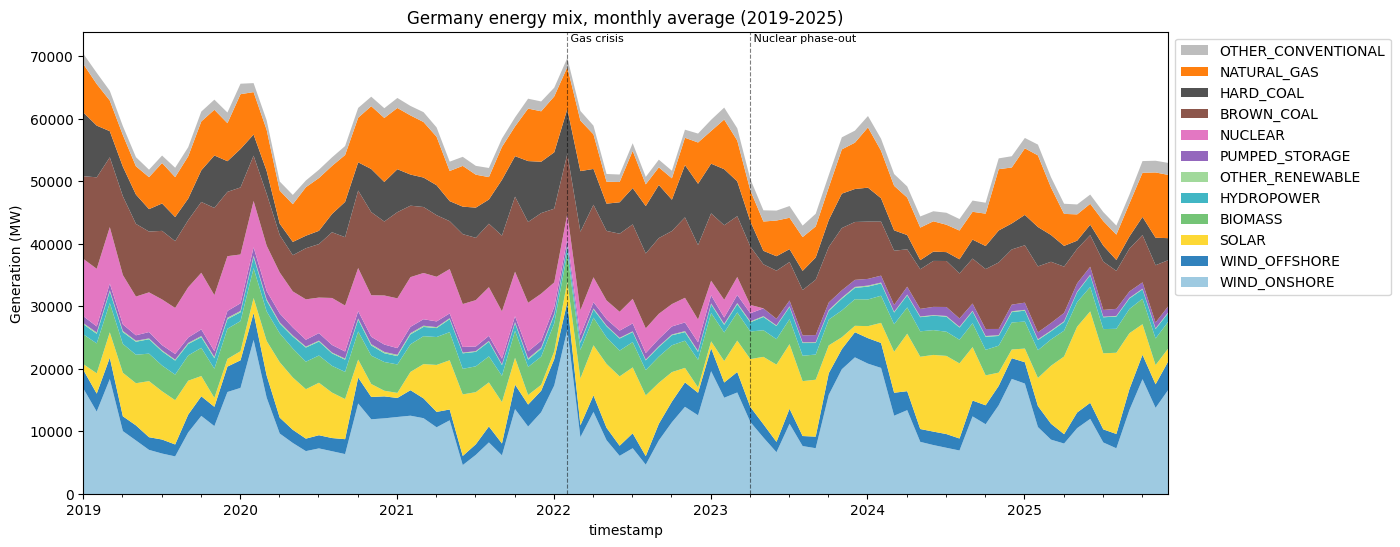

In [9]:
ax = monthly[STACK_ORDER].plot.area(
    color=[COLORS[c] for c in STACK_ORDER],
    figsize=(14, 6),
    linewidth=0,
)
ax.set_title("Germany energy mix, monthly average (2019-2025)")
ax.set_ylabel("Generation (MW)")
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), reverse=True)


ax.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(pd.Timestamp("2023-04-15"), color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.text(pd.Timestamp("2022-02-24"), 72000, " Gas crisis", fontsize=8, va="bottom")
ax.text(pd.Timestamp("2023-04-15"), 72000, " Nuclear phase-out", fontsize=8, va="bottom")

Total German electricity generation has declined substantially. That's an ~18% decline in winter peak generation across the window. Summer minima dropped similarly. This is real and it's not just "renewables replacing fossils" — the total stack height is shrinking. The story is something like:
- Energy efficiency improvements
- Heavy industry reducing output or relocating (especially energy-intensive sectors like chemicals and steel, hit hard by 2022 prices)
- Increased imports from neighbours (cheaper renewable power from Scandinavia, French nuclear)
- Heat pump growth offsetting some industrial decline but not enough

In [10]:
# Annual total generation
annual_gen = monthly.sum(axis=1).resample("YS").mean()
print(annual_gen)

# Annual total consumption (for comparison)
annual_load = (
    df.set_index("timestamp")["TOTAL_CONSUMPTION"]
    .resample("YS").mean()
)
print(annual_load)

# Generation - consumption = net export (positive = exporting)
print((annual_gen - annual_load).rename("net_export_proxy"))

timestamp
2019-01-01 00:00:00+00:00    59556.439771
2020-01-01 00:00:00+00:00    57354.058793
2021-01-01 00:00:00+00:00    58397.050332
2022-01-01 00:00:00+00:00    57161.136683
2023-01-01 00:00:00+00:00    51831.874099
2024-01-01 00:00:00+00:00    49851.506414
2025-01-01 00:00:00+00:00    50025.405081
Freq: YS-JAN, dtype: float64
timestamp
2019-01-01 00:00:00+00:00    56777.146832
2020-01-01 00:00:00+00:00    55254.770719
2021-01-01 00:00:00+00:00    57602.840696
2022-01-01 00:00:00+00:00    55055.979366
2023-01-01 00:00:00+00:00    52326.890011
2024-01-01 00:00:00+00:00    52995.267450
2025-01-01 00:00:00+00:00    53175.349807
Freq: YS-JAN, Name: TOTAL_CONSUMPTION, dtype: float64
timestamp
2019-01-01 00:00:00+00:00    2779.292939
2020-01-01 00:00:00+00:00    2099.288074
2021-01-01 00:00:00+00:00     794.209636
2022-01-01 00:00:00+00:00    2105.157317
2023-01-01 00:00:00+00:00    -495.015912
2024-01-01 00:00:00+00:00   -3143.761036
2025-01-01 00:00:00+00:00   -3149.944726
Freq: YS-JAN

* 2019: +2,779 MW   ← net exporter
* 2020: +2,099 MW
* 2021:   +794 MW   ← collapsing margin
* 2022: +2,105 MW   ← brief return (neighbours needed power during the crisis)
* 2023:   -495 MW   ← flipped sign — net importer
* 2024: -3,144 MW   ← decisively importing
* 2025: -3,150 MW   ← stabilized at -3 GW

## Section 3 — Renewable share evolution

In [11]:
# Energy-weighted (industry-standard)
yearly_renew = df.groupby(df["timestamp"].dt.year)[RENEWABLE_SOURCES].sum().sum(axis=1)
yearly_total = df.groupby(df["timestamp"].dt.year)[GENERATION_SOURCES_NO_STORAGE].sum().sum(axis=1)
yearly_share_weighted = yearly_renew / yearly_total
print(yearly_share_weighted)

timestamp
2019    0.435517
2020    0.473328
2021    0.426187
2022    0.476280
2023    0.567453
2024    0.599588
2025    0.602227
dtype: float64


The 2022→2023 jump (+9.1 points in one year) is bigger than any other year-over-year change. But it's partly definitional, not pure growth. When nuclear (~10% of generation) was phased out:

- Nuclear leaves the denominator (total shrinks)
- Even if renewables held flat in absolute MW, their percentage would mechanically increase
- So part of the 9.1-point jump is "the denominator got smaller"

In [12]:
# Absolute generation by group, annually
yearly_by_group = pd.DataFrame({
    "renewable_MW": df.groupby(df["timestamp"].dt.year)[RENEWABLE_SOURCES].mean().sum(axis=1),
    "nuclear_MW": df.groupby(df["timestamp"].dt.year)[NUCLEAR_SOURCES].mean().sum(axis=1),
    "fossil_MW": df.groupby(df["timestamp"].dt.year)[FOSSIL_SOURCES].mean().sum(axis=1),
    "total_MW": df.groupby(df["timestamp"].dt.year)[GENERATION_SOURCES_NO_STORAGE].mean().sum(axis=1)
})

print(yearly_by_group)

           renewable_MW   nuclear_MW     fossil_MW      total_MW
timestamp                                                       
2019       25491.871632  8109.731450  24930.803853  58532.406935
2020       26555.290813  6935.786231  22612.242401  56103.319444
2021       24473.629823  7465.884304  25485.173716  57424.687842
2022       26631.726741  3746.989070  25537.456707  55916.172517
2023       28720.919463   769.210017  21123.582848  50613.712329
2024       29164.785263     0.000000  19476.630094  48641.415357
2025       29424.343043     0.000000  19434.849969  48859.193013


Share went from 47.6% to 56.7% — a 9.1-point jump. Decomposing:

- Hold renewables flat at 26,633 in the new denominator: 26,633 / 48,525 = 54.9%
- That's a +7.3 point increase just from the denominator shrinking (nuclear leaving + fossil declining)
- Then renewables growing from 26,633 to 28,720: 56.7% - 54.9% = +1.8 points

2021 was a weak renewable year. Renewable generation actually dropped from 26,560 MW in 2020 to 24,475 MW in 2021 — the only year-over-year decline in the window. This is the European "wind drought of 2021" showing up in your data. It's a documented event (low wind speeds across northwest Europe for most of 2021, particularly in Q3).

Renewable growth has plateaued 2024–2025. From 29,150 to 29,420 MW — only 270 MW growth in a year. Compare to the ~2 GW jumps in 2022 and 2023. Either capacity additions slowed or 2025 had less favourable wind/solar conditions (or both).

## Section 4 — Nuclear phase-out (the focused story)

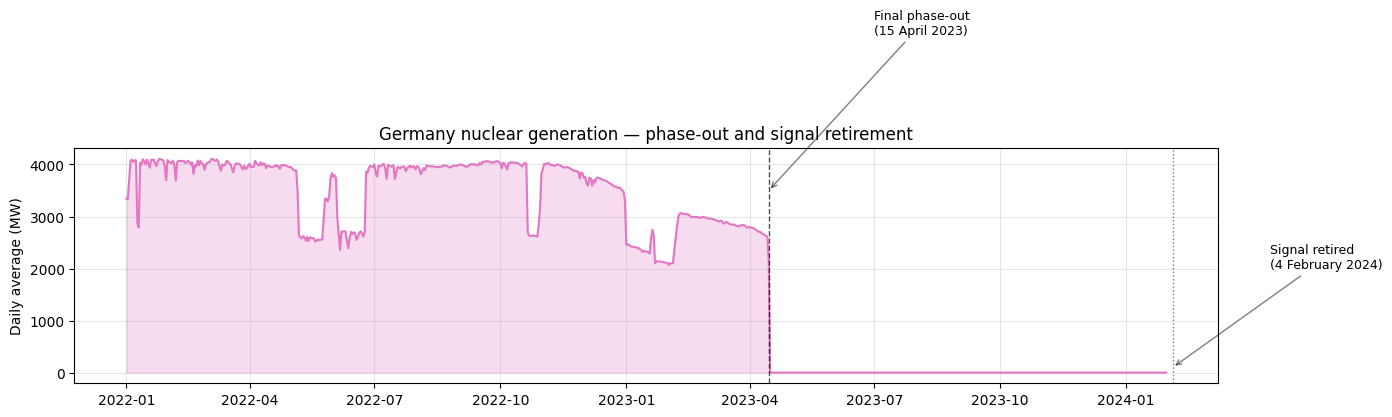

In [13]:
nuclear_daily = (
    df.set_index("timestamp")["NUCLEAR"]
    .resample("D").mean()
    .loc["2022-01-01":]   # zoom to the relevant window
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(nuclear_daily.index, nuclear_daily.values,
        color=COLORS["NUCLEAR"], linewidth=1.5)
ax.fill_between(nuclear_daily.index, nuclear_daily.values,
                alpha=0.25, color=COLORS["NUCLEAR"])

# Two structural breaks
ax.axvline(pd.Timestamp("2023-04-15"), color="black",
           linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(pd.Timestamp("2024-02-04"), color="black",
           linestyle=":", linewidth=1, alpha=0.5)

ax.annotate("Final phase-out\n(15 April 2023)",
            xy=(pd.Timestamp("2023-04-15"), 3500),
            xytext=(pd.Timestamp("2023-07-01"), 6500),
            fontsize=9,
            arrowprops=dict(arrowstyle="->", alpha=0.5))
ax.annotate("Signal retired\n(4 February 2024)",
            xy=(pd.Timestamp("2024-02-04"), 100),
            xytext=(pd.Timestamp("2024-04-15"), 2000),
            fontsize=9,
            arrowprops=dict(arrowstyle="->", alpha=0.5))

ax.set_title("Germany nuclear generation — phase-out and signal retirement")
ax.set_ylabel("Daily average (MW)")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5 — The coal story

Brown coal + hard coal stacked over time. Two interesting beats: the long-term decline (Energiewende policy) and the 2022 bounce (gas became expensive during the crisis, so Germany temporarily burned more coal). Both should be visible. Compute the year-over-year change in coal generation as a small table.

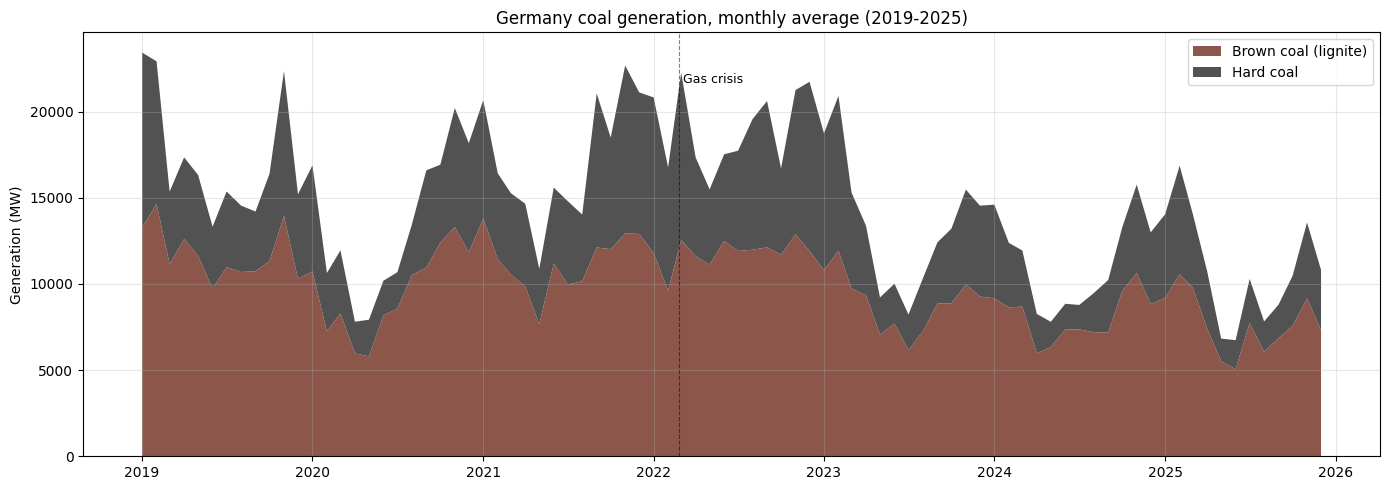

           BROWN_COAL  HARD_COAL  TOTAL_COAL  YoY_change
timestamp                                               
2019          11727.0     5458.0     17186.0         NaN
2020           9492.0     3970.0     13462.0     -3724.0
2021          11209.0     5918.0     17127.0      3665.0
2022          11818.0     7179.0     18997.0      1870.0
2023           8886.0     4538.0     13424.0     -5573.0
2024           8081.0     3112.0     11193.0     -2230.0
2025           7667.0     3215.0     10882.0      -311.0


In [14]:
coal_monthly = df.set_index("timestamp")[COAL_SOURCES].resample("MS").mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    coal_monthly.index,
    coal_monthly[ENERGY_SOURCE.BROWN_COAL.name],
    coal_monthly[ENERGY_SOURCE.HARD_COAL.name],
    labels=["Brown coal (lignite)", "Hard coal"],
    colors=[COLORS[ENERGY_SOURCE.BROWN_COAL.name], COLORS[ENERGY_SOURCE.HARD_COAL.name]],
    linewidth=0,
)

ax.axvline(pd.Timestamp("2022-02-24"), color="black",
           linestyle="--", linewidth=0.8, alpha=0.5)
ax.text(pd.Timestamp("2022-02-24"), coal_monthly.sum(axis=1).max() * 0.95,
        " Gas crisis", fontsize=9, va="top")

ax.set_title("Germany coal generation, monthly average (2019-2025)")
ax.set_ylabel("Generation (MW)")
ax.set_xlabel("")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Annual summary table — the bulge quantified
coal_annual = df.groupby(df["timestamp"].dt.year)[COAL_SOURCES].mean()
coal_annual["TOTAL_COAL"] = coal_annual.sum(axis=1)
coal_annual["YoY_change"] = coal_annual["TOTAL_COAL"].diff()
print(coal_annual.round(0))

- 2019–2022: coal stayed roughly in the 14–18 GW average range. Gas crisis prevented the decline that policy expected.
- 2023 onward: the real decline kicks in. Coal drops to 10–12 GW average and keeps falling.

Coal decline was delayed by the 2022 crisis. From 2019 to 2022, total coal stayed at ~14-18 GW average — the crisis kept fossil generation high as gas became unaffordable. The structural decline only began in 2023, dropping to ~7-8 GW average by 2025.

## Section 6 — Wind and solar growth

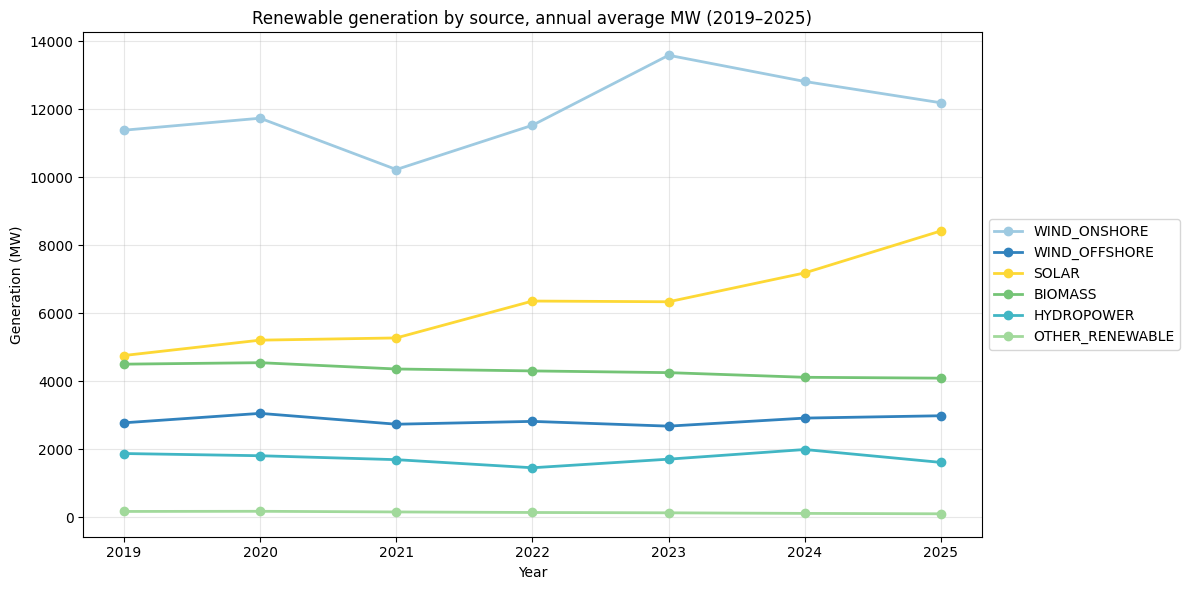


Annual renewable generation by source (MW):
           WIND_ONSHORE  WIND_OFFSHORE   SOLAR  BIOMASS  HYDROPOWER  \
timestamp                                                             
2019            11383.0         2783.0  4761.0   4507.0      1880.0   
2020            11735.0         3060.0  5212.0   4550.0      1815.0   
2021            10227.0         2742.0  5278.0   4365.0      1700.0   
2022            11528.0         2825.0  6362.0   4308.0      1462.0   
2023            13585.0         2685.0  6341.0   4257.0      1715.0   
2024            12815.0         2922.0  7189.0   4121.0      1998.0   
2025            12188.0         2990.0  8423.0   4095.0      1619.0   

           OTHER_RENEWABLE  
timestamp                   
2019                 178.0  
2020                 182.0  
2021                 163.0  
2022                 147.0  
2023                 138.0  
2024                 121.0  
2025                 109.0  


In [15]:
renewable_annual = (
    df.groupby(df["timestamp"].dt.year)[RENEWABLE_SOURCES]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))
for col in RENEWABLE_SOURCES:
    ax.plot(renewable_annual.index, renewable_annual[col],
            marker="o", label=col, color=COLORS[col], linewidth=2)

ax.set_title("Renewable generation by source, annual average MW (2019–2025)")
ax.set_ylabel("Generation (MW)")
ax.set_xlabel("Year")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAnnual renewable generation by source (MW):")
print(renewable_annual.round(0))

- Wind onshore has declined two years running (2023 peak 13.6 GW → 2024 12.8 → 2025 12.1 GW). Net renewable plateau is being held up by solar growth offsetting wind decline.

## Section 7 — 2019 vs 2025 side-by-side

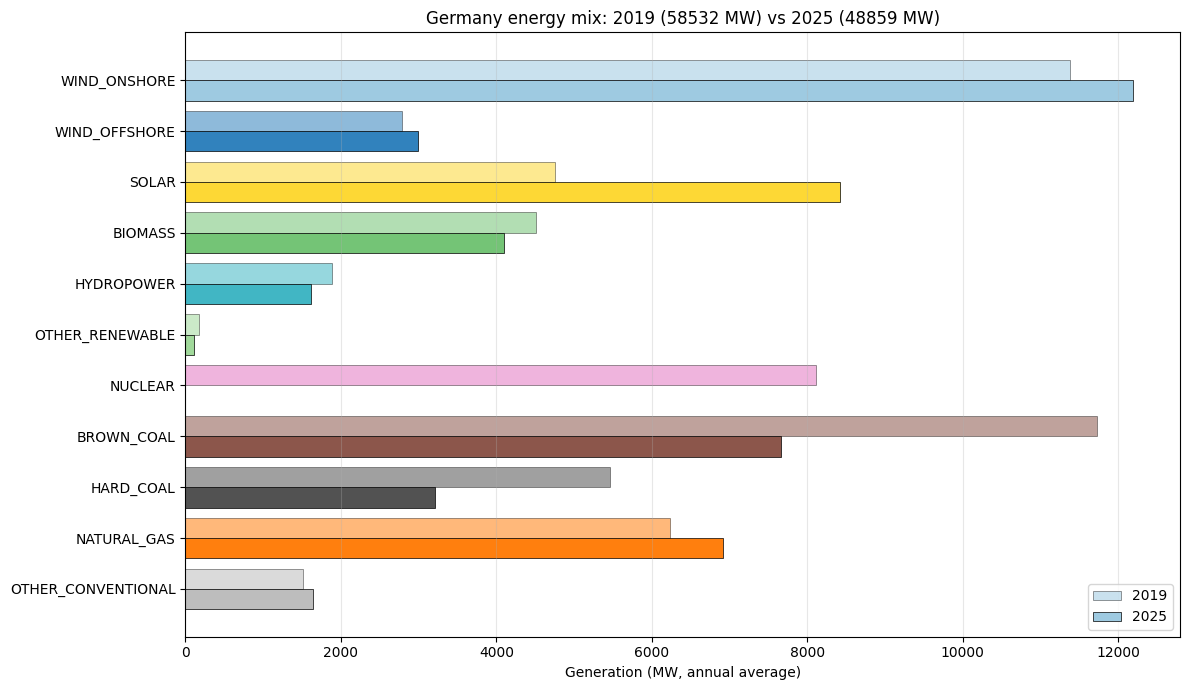


Change 2019 → 2025 (MW), sorted:
SOLAR                 3662.0
WIND_ONSHORE           805.0
NATURAL_GAS            677.0
WIND_OFFSHORE          207.0
OTHER_CONVENTIONAL     131.0
OTHER_RENEWABLE        -69.0
HYDROPOWER            -261.0
BIOMASS               -411.0
HARD_COAL            -2244.0
BROWN_COAL           -4060.0
NUCLEAR              -8110.0
Name: change, dtype: float64


In [16]:
mix = pd.DataFrame({
    "2019": df[df["timestamp"].dt.year == 2019][GENERATION_SOURCES_NO_STORAGE].mean(),
    "2025": df[df["timestamp"].dt.year == 2025][GENERATION_SOURCES_NO_STORAGE].mean(),
}).fillna(0)

mix["change"] = mix["2025"] - mix["2019"]

# Reindex in the same stack order minus pumped storage
order = [s for s in STACK_ORDER if s != ENERGY_SOURCE.PUMPED_STORAGE.name]
mix = mix.reindex(order)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(mix))
bar_width = 0.4
bar_colors = [COLORS[c] for c in mix.index]

ax.barh(y_pos - bar_width/2, mix["2019"], bar_width,
        color=bar_colors, alpha=0.55, edgecolor="black",
        linewidth=0.5, label="2019")
ax.barh(y_pos + bar_width/2, mix["2025"], bar_width,
        color=bar_colors, edgecolor="black",
        linewidth=0.5, label="2025")

ax.set_yticks(y_pos)
ax.set_yticklabels(mix.index)
ax.invert_yaxis()
ax.set_xlabel("Generation (MW, annual average)")
ax.set_title(
    f"Germany energy mix: 2019 ({mix['2019'].sum():.0f} MW) "
    f"vs 2025 ({mix['2025'].sum():.0f} MW)"
)
ax.grid(True, axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("\nChange 2019 → 2025 (MW), sorted:")
print(mix["change"].round(0).sort_values(ascending=False))

- Natural gas is the only fossil source that grew (2019 6.2 GW → 2025 6.9 GW). Despite the 2022 price crisis, gas's role as a flexible balancing technology to renewables has kept it in the mix while coal declined sharply.

## Section 8 — Findings

### Energy mix evolution (2019–2025)

1. Germany became a net electricity importer in 2023.
2. Nuclear: complete and rapid exit (~8 GW → 0 in 9 months, signal retired Feb 2024).
3. Renewable share grew from 43.6% to 60.2%, but ~80% of the 2023 jump
   came from denominator effects (nuclear leaving + fossil declining)
   rather than from renewable growth.
4. **Renewable absolute generation has plateaued.** Wind onshore has
   declined two years running (13.6 → 12.8 → 12.1 GW from 2023 to 2025);
   only solar growth has prevented total renewable decline.
5. Coal decline was delayed by the 2022 crisis. Structural decline only
   began in 2023, dropping coal generation by ~7 GW from 2022 to 2025.
6. **Natural gas is the only fossil source that grew** (6.2 → 6.9 GW),
   reflecting its structural role as a flexible balancing technology
   to variable renewables.
7. Total generation declined by ~9.7 GW (58.5 GW → 48.9 GW), almost
   exactly matching the lost nuclear capacity.
8. 2021 European wind drought: the only year-over-year renewable decline
   in the window (-2 GW vs 2020).